# Level 2: Time Series Models (BSTS)
### *Principled counterfactual — but cannot anticipate organic BF demand*

BSTS (Google's CausalImpact) learns trend and seasonality from the pre-period
and extrapolates forward as the counterfactual. This fixes before/after's window-sensitivity problem and YoY's comparability problem — the counterfactual is a model-based projection, not a naive average or a prior year comparison.

**What it does well here:** The pre-BF counterfactual (~1,808 USD/day) closely
tracks the actual Oct-Nov mean (1,807 USD/day). The model correctly learns
the trend-shifted baseline — it is not fooled by the growth acceleration.

**Where it fails:**
The pre-BF period is training data — fitted values tracking actuals is expected, not a signal of model quality. The real test is the BF window, which is out-of-sample. The counterfactual stays near 1,800 USD/day during BF while actual revenue spikes to 4,241 USD/day. The gap contains two things the model cannot separate: the organic BF demand spike and the paid campaign contribution. The model attributes the entire gap to the campaign.

**Why the counterfactual under-estimates the spike:** The BSTS seasonal component partially learned from BF 2024 — it knows late November is elevated. But the weekly seasonal bin averages BF days with surrounding days, so the model learns a moderate seasonal lift rather than a sharp one. The counterfactual is not truly flat — it shows some Q4 elevation — but it significantly under-estimates the BF spike magnitude. Had the model correctly forecast a BF spike based on 2024 data, that predicted spike would itself contain 2024 organic demand and 2024 paid campaign contribution — so the remaining gap would reflect only the year-over-year change in each, not a clean read on either.

The result is something close to a trend-adjusted YoY — total BF performance above the pre-BF modeled level, with organic demand and campaign contribution conflated throughout.

**Ground truth: 1,340 USD/day = 71.6% of Nov pre-BF baseline**

R required: https://cran.r-project.org/bin/macosx/

In [1]:
import sys, subprocess
sys.path.append('../src')
subprocess.run(['pip','install','rpy2','--break-system-packages','-q'], check=False)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

from utils import (
    load_dataset, get_treated_series, set_style, save_figure,
    add_intervention_band, add_trend_shift_line, format_date_axis, usd_formatter,
    compute_bf_effect, INTERVENTION_START, INTERVENTION_END, PALETTE, DATA_DIR
)
from generate_data import generate_dataset

set_style()
df, gt = generate_dataset(seed=42, data_dir=DATA_DIR)
ts     = get_treated_series(df)
TRUE_DAILY = gt['true_increment_usd']

Saved: dataset.csv  (4,386 rows)


## 0. Install R packages (run once)

In [2]:
ro.r('''
pkgs <- c('data.table','CausalImpact','zoo','scales','bsts')
for (pkg in pkgs) {
    if (!requireNamespace(pkg, quietly=TRUE))
        install.packages(pkg, repos='https://cran.r-project.org', quiet=TRUE)
    suppressPackageStartupMessages(library(pkg, character.only=TRUE))
}
cat('R packages ready\n')
''')

R packages ready


## 1. Run CausalImpact — weekly + annual seasonality

In [3]:
ts_vals  = ts.values.tolist()
dates    = [str(d.date()) for d in ts.index]
pre_end  = str((INTERVENTION_START - pd.Timedelta(days=1)).date())
post_end = str(ts.index.max().date())

ro.globalenv['y_v']     = ro.FloatVector(ts_vals)
ro.globalenv['pre_s']   = '2024-01-01'
ro.globalenv['pre_e']   = pre_end
ro.globalenv['post_s']  = str(INTERVENTION_START.date())
ro.globalenv['post_e']  = post_end
ro.globalenv['dates_v'] = ro.StrVector(dates)

print('Running CausalImpact (BF 2024 in pre-period, weekly + annual seasonality)...')
ro.r('''
library(CausalImpact); library(bsts); library(zoo)
ts_zoo <- zoo(y_v, order.by=as.Date(dates_v))
pre_period  <- as.Date(c(pre_s, pre_e))
post_period <- as.Date(c(post_s, post_e))
post_response <- window(ts_zoo, start=post_period[1], end=post_period[2])
ts_train      <- ts_zoo
window(ts_train, start=post_period[1], end=post_period[2]) <- NA
ss <- list()
ss <- AddLocalLevel(ss, ts_train)
ss <- AddSeasonal(ss, ts_train, nseasons=7,  season.duration=1)
ss <- AddSeasonal(ss, ts_train, nseasons=52, season.duration=7)
bsts_model <- bsts(ts_train, state.specification=ss, niter=1000, seed=1, ping=0)
impact <- CausalImpact(bsts.model=bsts_model,
                       post.period.response=as.numeric(post_response))
''')
print('Done.')

Running CausalImpact (BF 2024 in pre-period, weekly + annual seasonality)...
Done.


## 2. Results

In [4]:
with localconverter(ro.default_converter + pandas2ri.converter):
    inf = ro.conversion.rpy2py(ro.r('as.data.frame(impact$series)'))
inf.index = ts.index

def gc(cols):
    for c in cols:
        if c in inf.columns: return inf[c].values.astype(float)
    raise KeyError(cols)

ci_res = pd.DataFrame({
    'actual':       gc(['response','actual']),
    'predicted':    gc(['point.pred','predicted','point_pred']),
    'lower_95':     gc(['point.pred.lower','point_pred_lower']),
    'upper_95':     gc(['point.pred.upper','point_pred_upper']),
    'point_effect': gc(['point.effect','point_effect']),
}, index=ts.index)

bf_ci   = compute_bf_effect(ci_res['actual'], ci_res['predicted'])
ci_err  = (bf_ci['daily_effect'] / TRUE_DAILY - 1) * 100

# Key diagnostic: what does the counterfactual look like during Oct-Nov (pre-BF)?
oct_nov = (ts.index >= '2025-10-01') & (ts.index < INTERVENTION_START)
print(f'Oct-Nov actual mean:        ${ts[oct_nov].mean():,.0f}/day')
print(f'Oct-Nov BSTS counterfactual:${ci_res["predicted"][oct_nov].mean():,.0f}/day  <- tracks trend correctly')
print(f'BF actual mean:             ${bf_ci["actual_mean"]:,.0f}/day')
print(f'BF BSTS counterfactual:     ${bf_ci["cf_mean"]:,.0f}/day  <- stays flat, misses organic demand')
print(f'BSTS estimate:              ${bf_ci["daily_effect"]:,.0f}/day  ({ci_err:+.0f}% vs ${TRUE_DAILY:,.0f} true)')
print(f'Organic demand double-counted: ~${bf_ci["daily_effect"] - TRUE_DAILY:,.0f}/day')

Oct-Nov actual mean:        $1,807/day
Oct-Nov BSTS counterfactual:$1,808/day  <- tracks trend correctly
BF actual mean:             $4,241/day
BF BSTS counterfactual:     $1,893/day  <- stays flat, misses organic demand
BSTS estimate:              $2,348/day  (+75% vs $1,340 true)
Organic demand double-counted: ~$1,008/day


## 3. Visualization — the flat BF counterfactual

Saved: 02_bsts.png


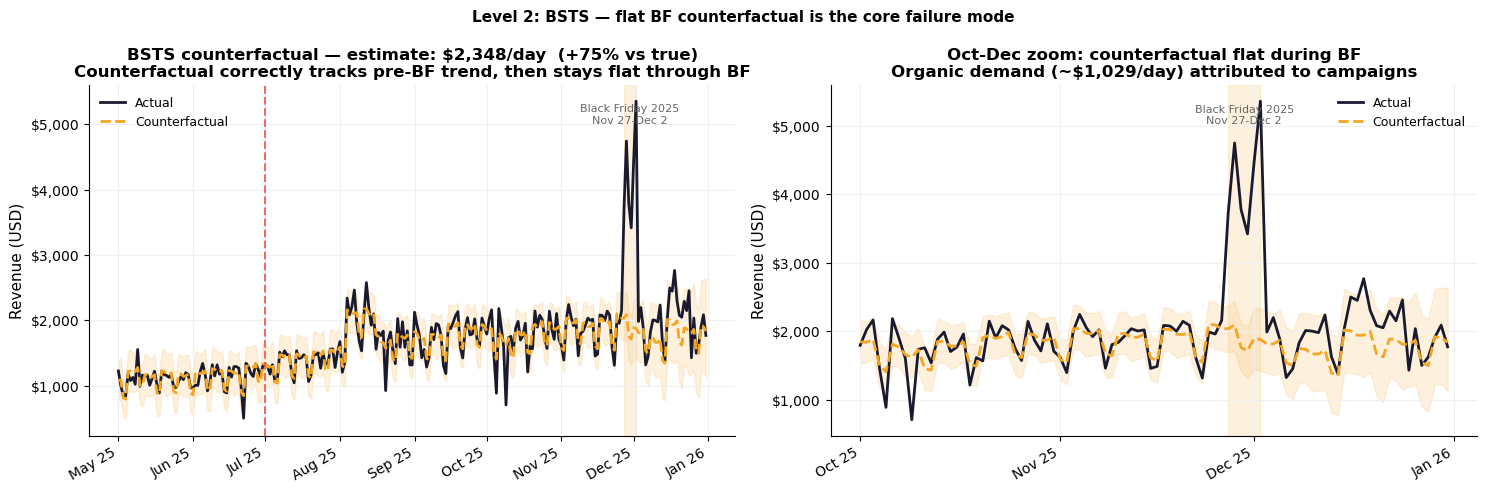


Stored for NB04: bsts_daily_effect = $2,348/day


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: full series
zm = np.array(ci_res.index >= '2025-05-01')
zd = np.array(ci_res.index[zm])
axes[0].plot(zd, ci_res['actual'].values[zm],    color=PALETTE['actual'], lw=2, label='Actual')
axes[0].plot(zd, ci_res['predicted'].values[zm], color=PALETTE['level2'], lw=2, ls='--', label='Counterfactual')
axes[0].fill_between(zd, ci_res['lower_95'].values[zm], ci_res['upper_95'].values[zm],
                     color=PALETTE['level2'], alpha=0.15)
add_intervention_band(axes[0])
add_trend_shift_line(axes[0], label=False)
format_date_axis(axes[0])
axes[0].set_title(
    f'BSTS counterfactual — estimate: ${bf_ci["daily_effect"]:,.0f}/day  ({ci_err:+.0f}% vs true)\n'
    'Counterfactual correctly tracks pre-BF trend, then stays flat through BF'
)
axes[0].set_ylabel('Revenue (USD)')
axes[0].yaxis.set_major_formatter(usd_formatter())
axes[0].legend(fontsize=9)

# Panel 2: zoom Oct-Dec showing the flat BF counterfactual clearly
zm2 = np.array(ci_res.index >= '2025-10-01')
zd2 = np.array(ci_res.index[zm2])
axes[1].plot(zd2, ci_res['actual'].values[zm2],    color=PALETTE['actual'], lw=2, label='Actual')
axes[1].plot(zd2, ci_res['predicted'].values[zm2], color=PALETTE['level2'], lw=2, ls='--', label='Counterfactual')
axes[1].fill_between(zd2, ci_res['lower_95'].values[zm2], ci_res['upper_95'].values[zm2],
                     color=PALETTE['level2'], alpha=0.15)
add_intervention_band(axes[1])
format_date_axis(axes[1])
axes[1].set_title(
    'Oct-Dec zoom: counterfactual flat during BF\n'
    f'Organic demand (~${gt["organic_lift_obs_pct"]/100 * gt["ps_imm_pre_mean_usd"]:,.0f}/day) attributed to campaigns'
)
axes[1].set_ylabel('Revenue (USD)')
axes[1].yaxis.set_major_formatter(usd_formatter())
axes[1].legend(fontsize=9)

plt.suptitle('Level 2: BSTS — flat BF counterfactual is the core failure mode',
             fontsize=11, fontweight='bold')
plt.tight_layout()
save_figure(fig, '02_bsts')
plt.show()

# Store result for notebook 04
bsts_daily_effect = bf_ci['daily_effect']
print(f'\nStored for NB04: bsts_daily_effect = ${bsts_daily_effect:,.0f}/day')

## Summary

**What BSTS gets right:** The model correctly learns the trend-shifted baseline.

**What BSTS gets wrong:** During the BF window the counterfactual stays flat at 1,808 USD/day. It cannot anticipate organic BF consumer demand (1,008 USD/day). That organic lift is attributed entirely to paid campaigns, producing an estimate of 2,348 USD/day vs the true 1,340 USD/day — a 75% overstatement.

---

**Next:** `03_bsts_synthetic_control.ipynb` — SC donors also spike during BF, so their covariate values at the BF moment directly push the counterfactual up.